In [1]:
from mlexplainer.predictors import BinaryMLPredictor
from pandas import read_csv

/Users/zachariebuisson/Documents/GitHub/mlexplainer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = read_csv("./docs/demo/datasets/binary_datasets/bank.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
target = "Exited"
excluded_columns = [target, "RowNumber", "CustomerId", "Surname"]

In [4]:
for feat in df.columns:
    if df[feat].dtype == "object":
        df[feat] = df[feat].astype("category")

In [5]:
from pandas import concat, DataFrame
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Crée la pipeline avec une étape OneHotEncoder pour la colonne 'Geography'

class AdvancedOneHotEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = OneHotEncoder(handle_unknown='ignore')
        self.feature = None

    def fit(self, X, y=None):
        if "Geography" in X.columns:
            self.feature = ["Geography"]
            self.encoder.fit(X[self.feature])
        return self

    def transform(self, X):
        if self.feature:
            encoded = self.encoder.transform(X[self.feature])
            encoded_df = DataFrame(encoded.toarray(), columns=self.encoder.get_feature_names_out(self.feature), index=X.index)
            return concat([X.drop(columns=self.feature), encoded_df], axis=1)
        return X

# Transforme la colonne 'Geography'
AOHE = AdvancedOneHotEncoder()
df_test = AOHE.fit_transform(df)
df_test

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,Female,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,2,15647311,Hill,608,Female,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,3,15619304,Onio,502,Female,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,4,15701354,Boni,699,Female,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,5,15737888,Mitchell,850,Female,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,Male,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0
9996,9997,15569892,Johnstone,516,Male,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0
9997,9998,15584532,Liu,709,Female,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0
9998,9999,15682355,Sabbatini,772,Male,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0


In [6]:
from xgboost import XGBClassifier

model = XGBClassifier(enable_categorical=True)
model.fit(AOHE.transform(df.drop(columns=excluded_columns)), df[target])

predictor = BinaryMLPredictor(model, df.drop(columns=excluded_columns), pipeline=AOHE)
predictor.predict_with_contributions(df.drop(columns=excluded_columns).iloc[0:1, :])

{'prediction': 0.37878817319869995,
 'contributions': {'CreditScore': 0.2036,
  'Gender': 0.1947,
  'Age': 0.2427,
  'Tenure': 0.1126,
  'Balance': 0.1472,
  'NumOfProducts': 0.5326,
  'HasCrCard': -0.0225,
  'IsActiveMember': -0.4766,
  'EstimatedSalary': -0.0286,
  'Geography_France': 0.0069,
  'Geography_Germany': 0.1125,
  'Geography_Spain': 0.0264},
 'values_before_processing': {'CreditScore': 619,
  'Geography': 'France',
  'Gender': 'Female',
  'Age': 42,
  'Tenure': 2,
  'Balance': 0.0,
  'NumOfProducts': 1,
  'HasCrCard': 1,
  'IsActiveMember': 1,
  'EstimatedSalary': 101348.88},
 'values_after_processing': {'CreditScore': 619,
  'Gender': 'Female',
  'Age': 42,
  'Tenure': 2,
  'Balance': 0.0,
  'NumOfProducts': 1,
  'HasCrCard': 1,
  'IsActiveMember': 1,
  'EstimatedSalary': 101348.88,
  'Geography_France': 1.0,
  'Geography_Germany': 0.0,
  'Geography_Spain': 0.0}}

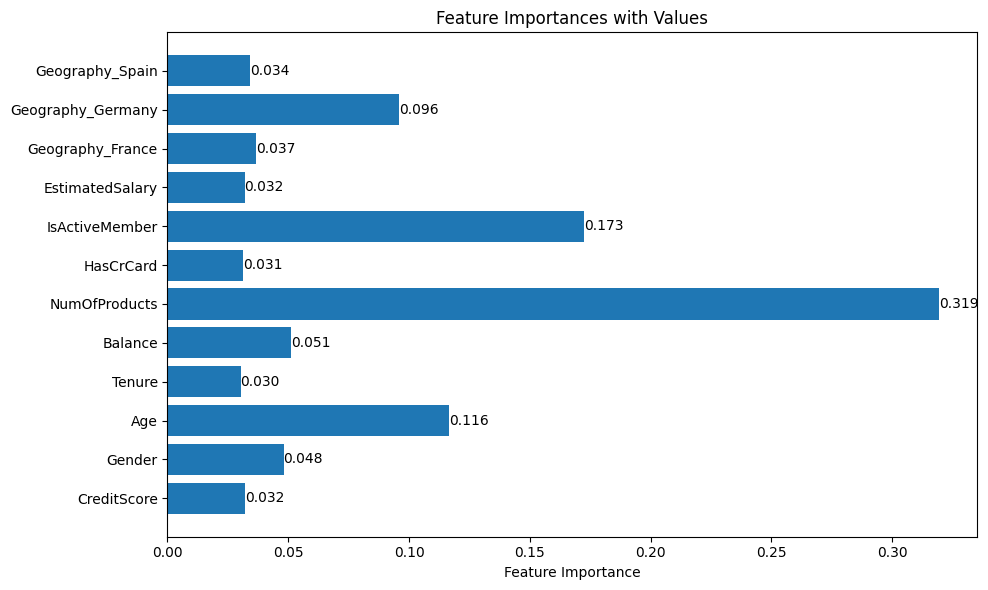

In [7]:
import matplotlib.pyplot as plt

feature_names = AOHE.transform(df.drop(columns=excluded_columns)).columns
importances = model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importances with Values")
for i, v in enumerate(importances):
    plt.text(v, i, f"{v:.3f}", va='center')
plt.tight_layout()
plt.show()

In [15]:
observation = df.drop(columns=excluded_columns).iloc[0:1, :]
mode = "llm"
language = "fr"
top_n = 3
target_name = "Exited"


results = predictor.predict_with_text_explanation(
    observation=observation,
    mode=mode,
    language=language,
    top_n=top_n,
    target_name=target_name,
    feature_name_mapping=None,
)

results["explanation_text"]

"La probabilité de quitter la base est de 38%. Le nombre de produits souscrits augmente la probabilité (+53.3%), tandis que le statut de membre actif diminue cette probabilité (-47.7%). L'âge du client influence également positivement la probabilité (+24.3%).\n\nCette analyse montre que plus un client a souscrit de produits, plus il a une chance de rester dans la base. Cependant, son statut de membre actif semble avoir une incidence négative sur sa probabilité de quitter. Enfin, l'âge du client joue un rôle important, augmentant la probabilité de rester dans la base."